# Supplementary Fig. 13 — distribution of final position-specific error rates, grouped by base change

Six panels — one per base-change category (each substitution together with its reverse complement) — each
showing the distribution of the **final per-position error rate** across **174,366** SNV/indel panel
positions, in a pilot set of **20 pre-AML + 20 control** UKCTOCS samples (sequencing lane **SLX_20124**).
The leftmost bar (plotted at a pseudo-zero on the log axis) is positions with an error rate of 0.

## Data availability

This notebook summarises the output of the position-specific error model, which is fitted in
**Supplementary Fig. 12** — run that notebook first and it writes the file below into `Data_files/`.
Rather than repeat several hours of fitting, this notebook reads that output and groups the fitted
per-position error rates by base change.

The error-model output is **not distributed with this code**: alongside the fitted values it holds
variant and total read depth for each of the 40 sample-timepoints on lane SLX_20124 at every panel
position, germline sites included, so it carries germline genotype information for every sample. It is
not deposited itself; Supplementary Fig. 12 produces it from the per-sample DCS all-positions VCFs, which
are deposited under controlled access in the European Genome-phenome Archive and released to approved
researchers via a Data Access Committee.

| file | used for | location |
|---|---|---|
| `SLX_20124_error_model_MLE_outcomes.csv` | fitted per-position error rate and dispersion, plus per-sample depths | written by Supplementary Fig. 12; not distributed |
| `SLX_20124_real_variants_called.csv` | positions where real variants were called, excluded from the error-rate calculation | written by Supplementary Fig. 12; not distributed |

The published figure was assembled from the six per-base-change panels produced by the loop below.

In [10]:
# imported packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def remove_brackets(position_details):
    return position_details.replace('(', '').replace(')', '').replace("'", '').replace(' ', '')

In [12]:
# Lists of colors for plots
c0 = (0.76, 0.76, 0.76)
c1 = (1.00, 0.18, 0.33);
c2 = (1.00, 0.23, 0.19);
c3 = (1.00, 0.58, 0.00);
c4 = (1.00, 0.80, 0.00);
c5 = (0.30, 0.85, 0.39);
c6 = (0.35, 0.78, 0.98);
c7 = (0.20, 0.67, 0.86);
c8 = (0.00, 0.48, 1.00);
c9 = (0.35, 0.34, 0.84);
c10 = (0.00, 0.31, 0.57);
c11 = (0.12, 0.29, 0.69);
c12 = (0.17, 0.17, 0.42);
c13 = (1.00, 1.00, 1.00);
c14 = (0.77, 0.04, 0.00);

In [ ]:
#define the colors from colorbrewer2
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'
# yellow = '#ffffd4'

# Import SLX_20124 error model output table

In [ ]:
df = pd.read_csv('Data_files/SLX_20124_error_model_MLE_outcomes.csv')
df = df[df['mean position depth']>0]

In [15]:
base_changes = ['C>T', 'C>G', 'C>A', 'T>C', 'T>G', 'T>A', 'G>T', 'G>C', 'G>A', 'A>T', 'A>C', 'A>G']

In [16]:
# base-change colours, matching the palette used for the mutational signatures in
# Supplementary Fig. 8c and in the published version of this figure
base_change_colors = {'C>T': "#ef3b2c",
                      'C>G': "#252525",
                      'C>A': "#9ecae1",
                      'T>C': "#a1d99b",
                      'T>G': "#fcc5c0",
                      'T>A': "#d9d9d9",
                      'G>A': "#ef3b2c",
                      'G>C': "#252525",
                      'G>T': "#9ecae1",
                      'A>G': "#a1d99b",
                      'A>C': "#fcc5c0",
                      'A>T': "#d9d9d9"}

In [ ]:
df_real = pd.read_csv('Data_files/SLX_20124_real_variants_called.csv')
df_real = df_real.rename(columns = {'Unnamed: 0': 'position_details'})
df_real['position_details'] = df_real['position_details'].apply(remove_brackets)

In [ ]:
df_real_list = df_real.values.tolist()
df_real_list

df_real_dict = {}

for i in df_real_list:
    position = i[0]
    sample_variants = []
    for sample in i[1:]:
        if isinstance(sample, str):
            sample_variants.append(sample)
    df_real_dict[position]=sample_variants

In [20]:
# Calculate total error rate across whole panel = sum variant reads/ sum depth reads for all samples not called as real

df_list = df.values.tolist()

variant_depths = []
total_depths = []

for i in df_list:
    position_info = i[0]+','+str(i[1])+','+i[2]+','+i[3]
    if position_info in df_real_dict.keys():
        real_variants_at_position = df_real_dict[position_info]
    else:
        real_variants_at_position = []
        
#     print(real_variants_at_position)
    for sample in i[6:46]:
#         print(sample)
        if ',' in sample:
            var_reads = int(sample.split(',')[0])
            depth_reads = int(sample.split(',')[1])
            sample_name = sample.split(',')[2]
        else:
            var_reads = 0
            depth_reads = 0
            sample_name = ''
        if sample_name not in real_variants_at_position:
            variant_depths.append(var_reads)
            total_depths.append(depth_reads)
#         else:
#             print(position_info+' '+sample_name)

In [21]:
total_error_rate_across_panel = np.sum(variant_depths)/np.sum(total_depths)
total_error_rate_across_panel

np.float64(2.6636882490515726e-05)

In [22]:
def total_error_rate_for_base_change(base_changes, df):
    change_df = df[(df['change']==base_change[0]) | (df['change']==base_change[1])]
    change_df_list = change_df.values.tolist()

    variant_depths = []
    total_depths = []

    for i in change_df_list:
        position_info = i[0]+','+str(i[1])+','+i[2]+','+i[3]
        if position_info in df_real_dict.keys():
            real_variants_at_position = df_real_dict[position_info]
        else:
            real_variants_at_position = []

    #     print(real_variants_at_position)
        for sample in i[6:46]:
    #         print(sample)
            if ',' in sample:
                var_reads = int(sample.split(',')[0])
                depth_reads = int(sample.split(',')[1])
                sample_name = sample.split(',')[2]
            else:
                var_reads = 0
                depth_reads = 0
                sample_name = ''
            if sample_name not in real_variants_at_position:
                variant_depths.append(var_reads)
                total_depths.append(depth_reads)
                
    return np.sum(variant_depths)/np.sum(total_depths)

In [28]:
def plot_error_rate_base_change(base_changes, df):
    pseudozero = 1e-6
    change_df = df[(df['change']==base_change[0]) | (df['change']==base_change[1])]
    change_df_list = change_df['final position error rate'].values.tolist()
    change_df_list_without_zero = []

    for i in change_df_list:
        if i == 0:
            change_df_list_without_zero.append(pseudozero)
        else:
            change_df_list_without_zero.append(i)

    fig, ax1 = plt.subplots(1, 1, figsize = (8, 6))
    ax1.hist(change_df_list_without_zero, bins=np.logspace(np.log10(9e-7),np.log10(1.0), 50), color = base_change_colors[base_change[0]], alpha = 1, lw = 1.5, edgecolor = grey5, histtype = 'stepfilled')
    ax1.set_xscale('log')

    for ax in [ax1]:
        ax.set_xlabel('position error rate (\u03B4)', fontsize = 16, labelpad = 14, fontweight = 'medium')
        ax.set_ylabel('positions', fontsize = 16, labelpad = 14, fontweight = 'medium')

        ax.xaxis.set_tick_params(width=1, color = grey3, length = 6)
        ax.yaxis.set_tick_params(width=1, color = grey3, length = 6)

        for item in (ax.get_xticklabels() + ax.get_yticklabels()):
            item.set_fontsize(14)

        #Only show the required axis lines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        for axis in ['bottom','left']:
            ax.spines[axis].set_linewidth(1)
            ax.spines[axis].set_color(grey3)

    ax1.set_title(base_change, fontsize = 16)
    ax1.set_yscale('log')
    
    ax1.set_ylim(0.5, 1e5)
    
    base_change_error_rate = total_error_rate_for_base_change(base_changes, df)
    
    ax1.plot([base_change_error_rate, base_change_error_rate], [0.5, 1e5], color = grey5, lw = 2, linestyle = ':')
    ax1.set_title(str(base_changes)+'\n(error rate = '+str(base_change_error_rate)+')', fontsize = 16)
    
    plt.tight_layout()

    return plt.show()

In [29]:
base_change_pairs = [('C>T', 'G>A'), ('C>G', 'G>C'), ('C>A', 'G>T'), ('T>C', 'A>G'), ('T>G', 'A>C'), ('T>A', 'A>T')]

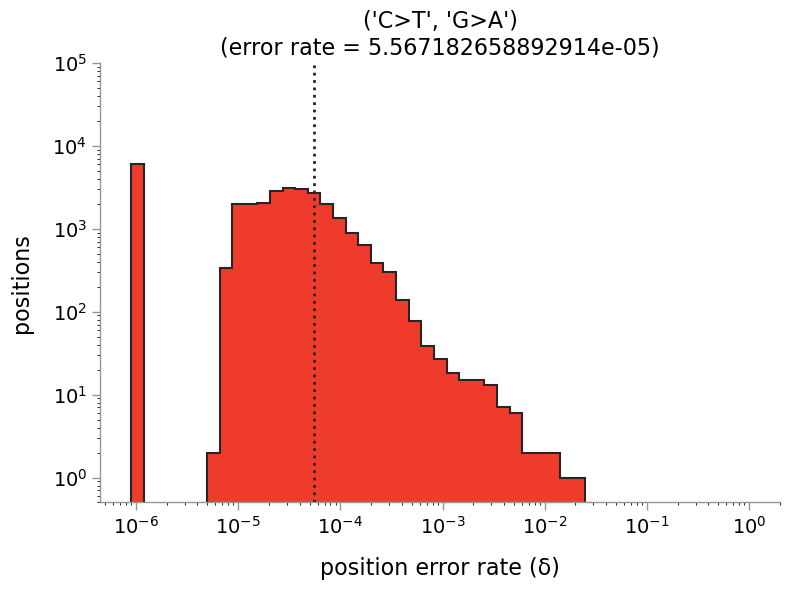

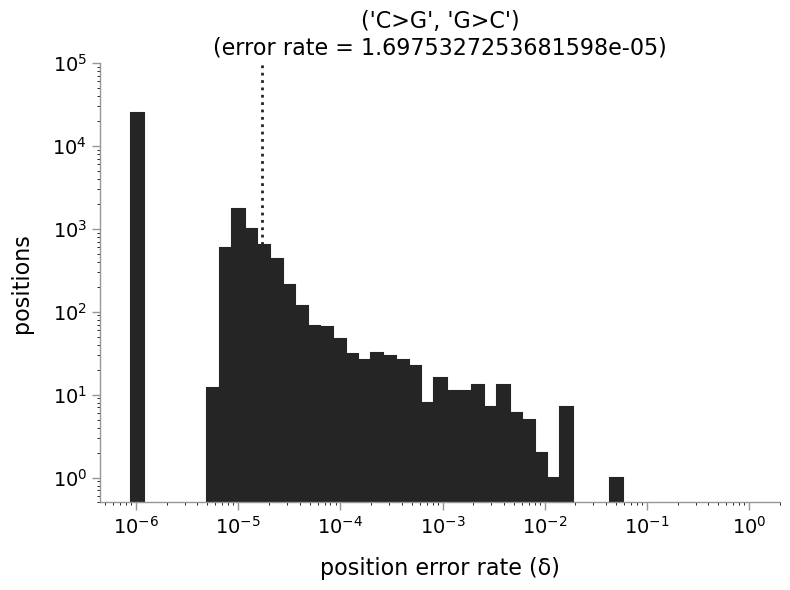

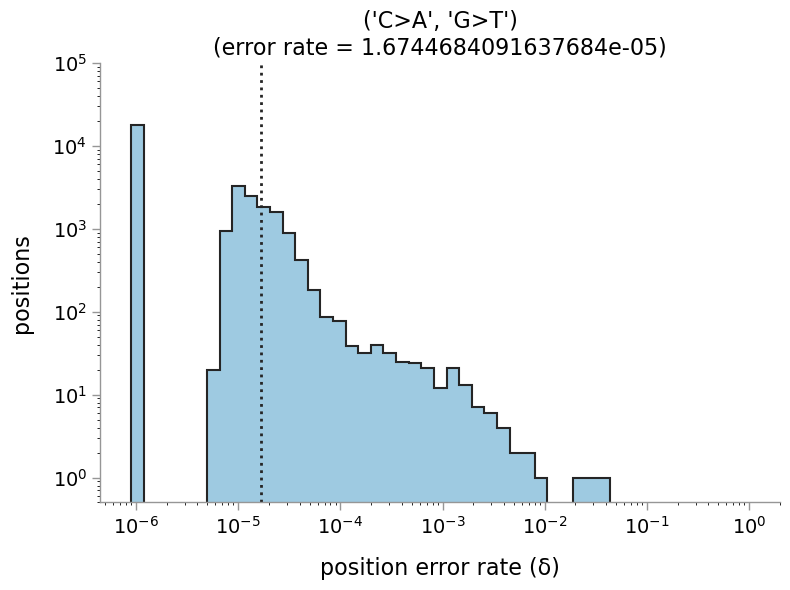

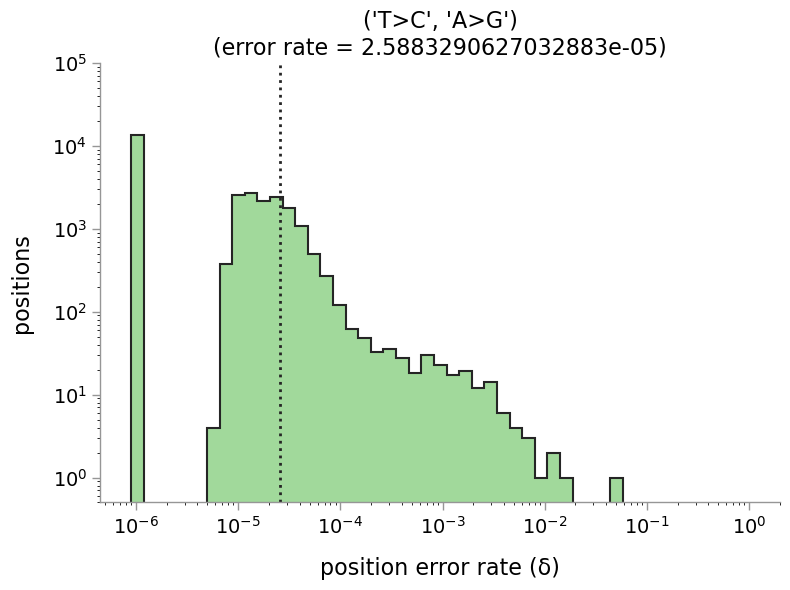

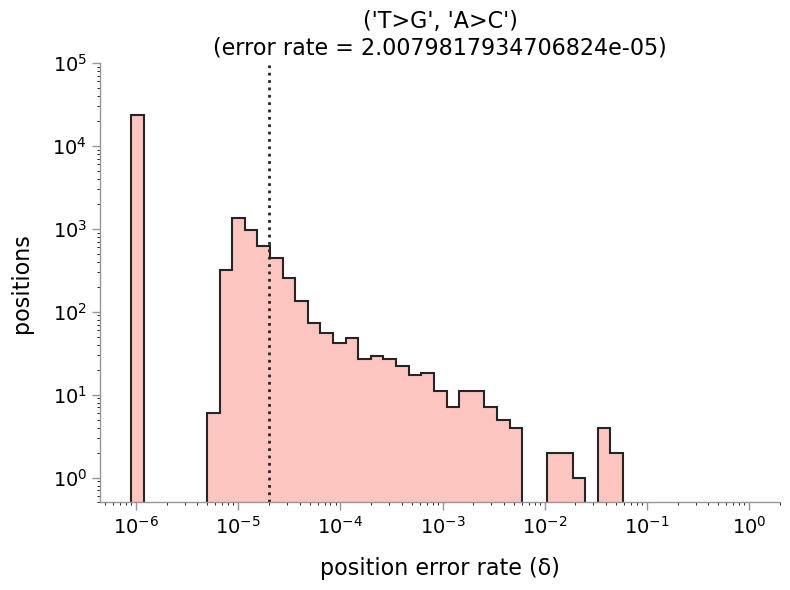

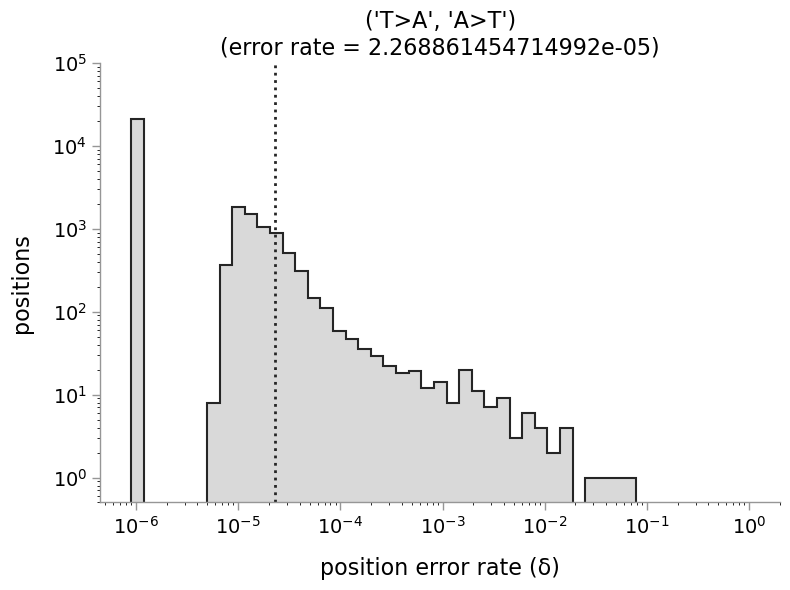

In [30]:
for base_change in base_change_pairs:
    plot_error_rate_base_change(base_change, df)